In [2]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import colorsys
import plotly.io as pio
pio.renderers.default = "browser" 

import altair as alt
from itertools import combinations
import numpy as np
import math
import pypangraph as pp
from Bio import Phylo, SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord


import random
import plotly.graph_objects as go
import plotly.express as px

import scipy.cluster.hierarchy as sch
from collections import defaultdict, deque, Counter
from Bio import Phylo

from pathlib import Path
import subprocess

from Bio.Phylo.TreeConstruction import DistanceCalculator
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from junction_analysis.helpers import get_tree_order, read_gff3_annotations, read_gff3_cds_products
from junction_analysis.junction_trees import build_tree_from_block_list, compute_pairwise_distances, cluster_tree_by_branch_length
import junction_analysis.pangraph_utils as pu
from junction_analysis.plotting import plot_junction_pangraph_interactive, plot_block_distance_distribution, plot_pairwise_distance_hist
from junction_analysis.consensus import find_consensus_paths, make_deduplicated_paths, filter_paths_by_block_freq, compute_majority_path, consensus_paths_and_assignments, find_consensus_paths_core, filter_deduplicated_paths
from junction_analysis.block_alignment import create_block_msas, summarize_block_msas, analyze_alignment, cluster_alignment, retrieve_cluster_assignments
from junction_analysis.annotate_insertions import get_insertions_deletions_from_consensus, write_insertions_fasta, summarize_deletions_consensus, load_all_deletions_summaries

In [2]:
junction_annotations_df = read_gff3_annotations("../results/junction_mges/RYYAQMEJGY_r__ZTHKZYHPIX_f.gff3")
junction_annotations_df

,seqid,feature,start,end,attrs,is_subtype
0,NZ_CP102061.1,IS,1969,2823,"{'ID': 'NZ_CP102061.1|IS66|1992', 'is_partial'...",IS66
1,NZ_CP102061.1,IS,2912,3795,"{'ID': 'NZ_CP102061.1|IS66|1993', 'is_partial'...",IS66
2,NZ_CP102061.1,IS,10409,10585,"{'ID': 'NZ_CP102061.1|IS3|1994', 'is_partial':...",IS3
3,NZ_CP102061.1,IS,12502,15033,"{'ID': 'NZ_CP102061.1|IS66|1995', 'is_partial'...",IS66
4,NZ_CP102061.1,IS,23139,23906,"{'ID': 'NZ_CP102061.1|IS1|1996', 'is_partial':...",IS1
...,...,...,...,...,...,...
2648,NZ_CP124515.1,IS,19177,19944,"{'ID': 'NZ_CP124515.1|IS1|6809', 'is_partial':...",IS1
2649,NZ_CP124515.1,IS,13470,15108,"{'ID': 'NZ_CP124515.1|IS630|6810', 'is_partial...",IS630
2650,NZ_CP124515.1,defense_system,17434,18510,"{'ID': 'NZ_CP124515.1_SoFic_8', 'is_partial': ...",None
2651,NZ_CP124515.1,defense_system,59976,64533,"{'ID': 'NZ_CP124515.1_RM_Type_II_10', 'is_part...",None


In [3]:
junction_name = "RYYAQMEJGY_r__ZTHKZYHPIX_f"
cds_products_df = read_gff3_cds_products(f"../results/junction_annotations/{junction_name}.gff")
cds_products_df.head()

,seqid,start,end,strand,product,attrs
0,NZ_CP102061.1,1,100740,+,terminase small subunit,"{'ID': 'NP943_RS00005', 'Name': 'NP943_RS00005..."
1,NZ_CP102061.1,1,994,-,NADPH-dependent aldehyde reductase Ahr,"{'ID': 'NP943_RS17000', 'Name': 'ahr', 'ec_num..."
2,NZ_CP102061.1,1461,1922,+,tyrosine-type recombinase/integrase,"{'ID': 'NP943_RS17010', 'Name': 'NP943_RS17010..."
3,NZ_CP102061.1,1904,2062,-,phosphoethanolamine transferase,"{'ID': 'NP943_RS17015', 'Name': 'NP943_RS17015..."
4,NZ_CP102061.1,2646,2876,+,transposase domain-containing protein,"{'ID': 'NP943_RS17020', 'Name': 'NP943_RS17020..."


Skipping core: FASTA, alignment and tree already exist in /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/consensus_analysis/CIRMBUYJFK_f__CWCCKOQCWZ_r
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}]
No ambiguous blocks.
160 / 170 isolates share the majority path
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {0}]
No ambiguous blocks.
52 / 52 isolates share the majority path


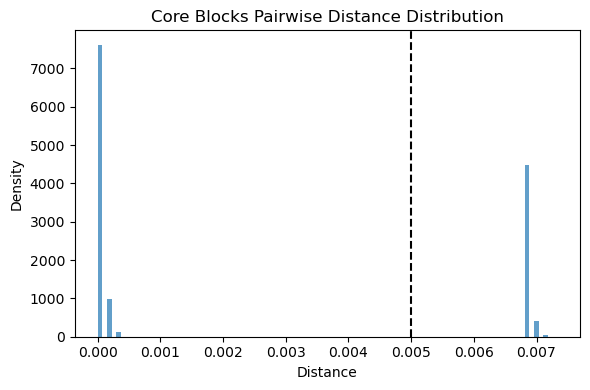

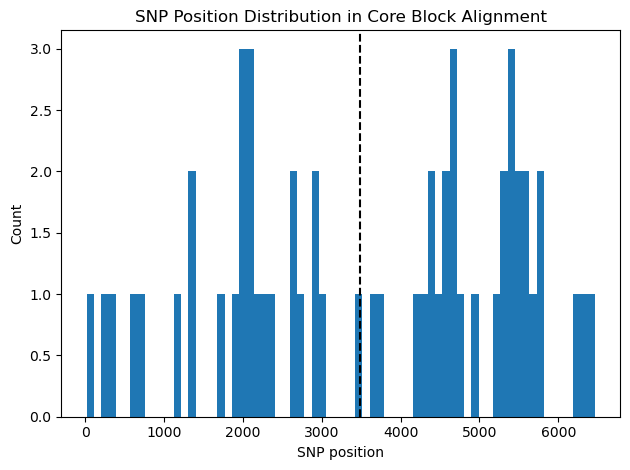

'\nfig = plot_junction_pangraph_interactive(\n    pangraph,\n    show_consensus=True,\n    consensus_paths=consensus_paths_plotting,\n    assignments=assignment_df_plotting,\n    order="tree",\n    cluster_map=cluster_map_core,\n    add_cluster_annotation=False,\n    title = "Junction Block Structure with Core Block Tree Clustering",\n    show_mges_annotations=True,\n    show_int_rec_annotations=True,\n    show_cds_annotations=False,\n    mges_gff_path=f"../results/junction_mges/{junction_name}.gff3",\n    annotations_gff_path=f"../results/junction_annotations/{junction_name}.gff",\n    annotation_alpha=0.7,\n    cds_annotation_alpha=0.3,\n)\ndisplay(fig)\n'

In [3]:
#junction_name = "RYYAQMEJGY_r__ZTHKZYHPIX_f"
#junction_name = "EJPOGALASQ_f__KUIFCLFQSI_r"
#junction_name = "JVNRLCFAVD_f__PLTCZQCVRD_r"
junction_name = "CIRMBUYJFK_f__CWCCKOQCWZ_r"
cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, all_root_states, all_root_states_unqiue = find_consensus_paths_core(junction_name, plot_consensus=True, plot_annotations=True,plot_pair_dist=True, plot_snp_dist= True, plot_ambiguities= True, clustering_bl_thresh=0.005, consensus_criterium='core_genome_tree', tree_path='../config/polished_tree.nwk')

pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{junction_name}.json")

"""
fig = plot_junction_pangraph_interactive(
    pangraph,
    show_consensus=True,
    consensus_paths=consensus_paths_plotting,
    assignments=assignment_df_plotting,
    order="tree",
    cluster_map=cluster_map_core,
    add_cluster_annotation=False,
    title = "Junction Block Structure with Core Block Tree Clustering",
    show_mges_annotations=True,
    show_int_rec_annotations=True,
    show_cds_annotations=False,
    mges_gff_path=f"../results/junction_mges/{junction_name}.gff3",
    annotations_gff_path=f"../results/junction_annotations/{junction_name}.gff",
    annotation_alpha=0.7,
    cds_annotation_alpha=0.3,
)
display(fig)
"""

In [4]:
fig = plot_junction_pangraph_interactive(
    pangraph,
    show_consensus=True,
    consensus_paths=consensus_paths_plotting,
    assignments=assignment_df_plotting,
    order="tree",
    cluster_map=cluster_map_core,
    add_cluster_annotation=False,
    title = "Junction Block Structure with Core Block Tree Clustering",
    show_mges_annotations=True,
    show_int_rec_annotations=True,
    show_cds_annotations=False,
    mges_gff_path=f"../results/junction_mges/{junction_name}.gff3",
    annotations_gff_path=f"../results/junction_annotations/{junction_name}.gff",
    annotation_alpha=0.7,
    cds_annotation_alpha=0.3,
    show_indels=True,                                                                 
    indels_base_path="../results/atb_lookup",                                            
    junction_name=junction_name,  
)
display(fig)